## Leitura do csv

In [2]:
# carregar csv
import pandas as pd
import os
cenario = "NDT_NOV_ABR"
method = "vwcd_0.95"
file_path = os.path.join('metrics', cenario, method + '.csv')
df = pd.read_csv(file_path)

## Matriz de Correlação dos Changepoints

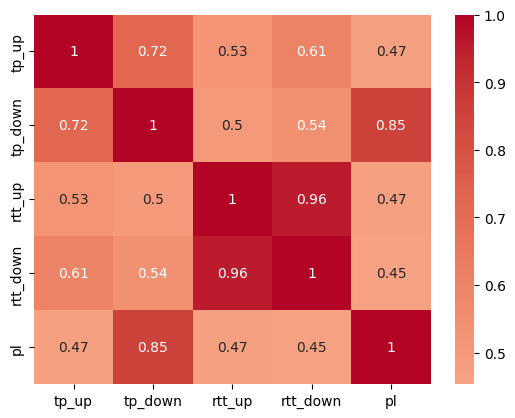

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
changepoints = ['tp_up', 'tp_down', 'rtt_up', 'rtt_down', 'pl']
correlation_matrix = df[changepoints].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

## Contagem de Changepoint por cliente/servidor

In [4]:
# Contar o número de clientes únicos e de servidores únicos
num_clientes_unicos = df['client'].nunique()
num_servidores_unicos = df['server'].nunique()
print(f"Número de clientes únicos: {num_clientes_unicos}")
print(f"Número de servidores únicos: {num_servidores_unicos}")

Número de clientes únicos: 16
Número de servidores únicos: 10


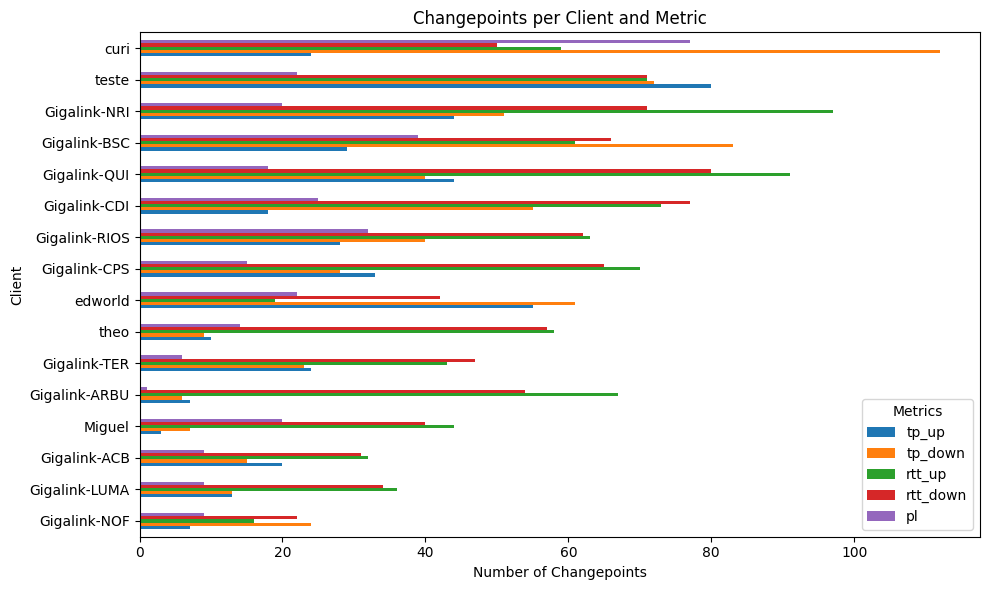

In [5]:
import matplotlib.pyplot as plt

df_grouped = df[['client']+changepoints].groupby('client').sum()
df_grouped = df_grouped.loc[df_grouped.sum(axis=1).sort_values(ascending=True).index]

ax = df_grouped.plot(kind='barh', figsize=(10, 6))
ax.set_title('Changepoints per Client and Metric')
ax.set_xlabel('Number of Changepoints')
ax.set_ylabel('Client')
ax.legend(title='Metrics')
plt.tight_layout()
plt.show()

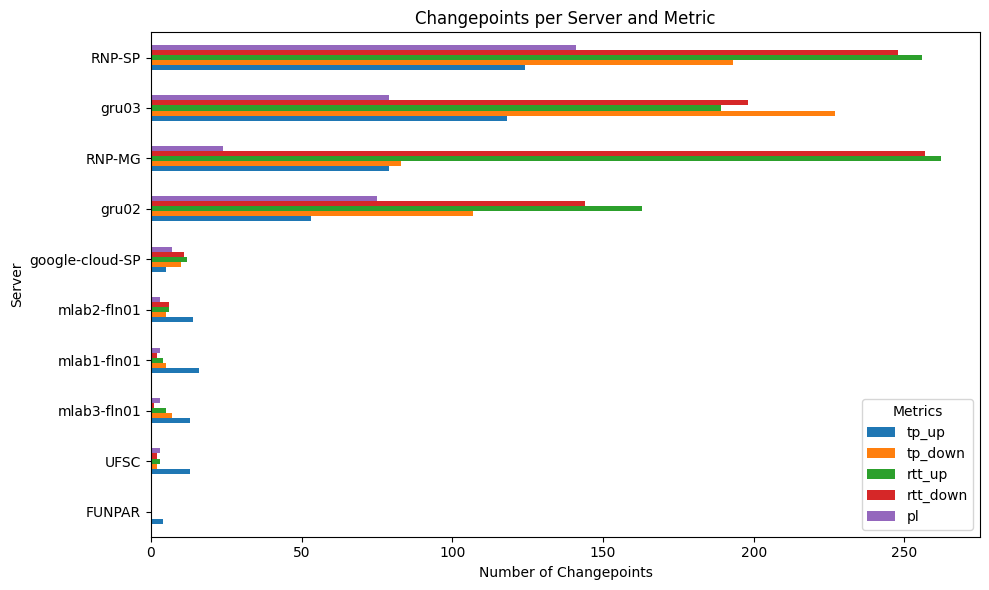

In [6]:
import matplotlib.pyplot as plt

df_grouped = df[['server']+changepoints].groupby('server').sum()
df_grouped = df_grouped.loc[df_grouped.sum(axis=1).sort_values(ascending=True).index]

ax = df_grouped.plot(kind='barh', figsize=(10, 6))
ax.set_title('Changepoints per Server and Metric')
ax.set_xlabel('Number of Changepoints')
ax.set_ylabel('Server')
ax.legend(title='Metrics')
plt.tight_layout()
plt.show()

# Relação entre métricas e número de changepoints

In [7]:
# normalizar a coluna tp_up_mean usando as colunas tp_up_min e tp_up_max
df['tp_up_m_norm'] = (df['tp_up_mean'] - df['tp_up_min']) / (df['tp_up_max'] - df['tp_up_min'])
# normalizar a coluna tp_down_mean usando as colunas tp_down_min e tp_down_max
df['tp_down_m_norm'] = (df['tp_down_mean'] - df['tp_down_min']) / (df['tp_down_max'] - df['tp_down_min'])

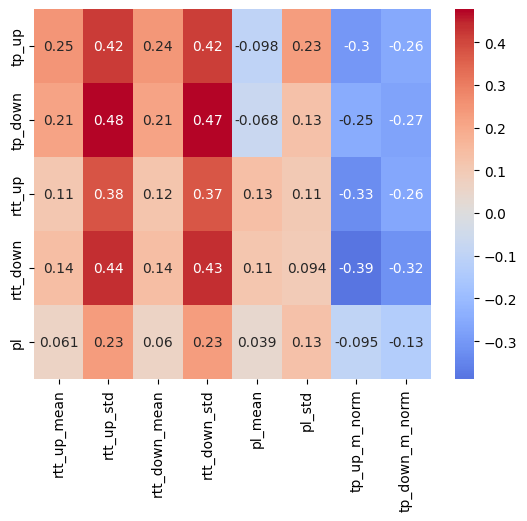

In [8]:
metrics = ["rtt_up_mean", "rtt_up_std", "rtt_down_mean", "rtt_down_std", "pl_mean", "pl_std", "tp_up_m_norm", "tp_down_m_norm"]
correlation_matrix = df[changepoints + metrics].corr().loc[changepoints, metrics]
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()